# Linear Regression Project — House Price Prediction

Yeh notebook ek basic **Machine Learning Regression** project hai jisme hum California Housing dataset use karke ghar ki price predict karte hain.

**Steps covered:**
1. Libraries import karna
2. Data load karna
3. Data cleaning
4. Exploratory Data Analysis (EDA)
5. Features aur Target alag karna
6. Train-Test Split
7. Feature Scaling (StandardScaler)
8. Model Training (Linear Regression)
9. Predictions
10. Model Evaluation (MAE, MSE, RMSE, R²)
11. Results Visualization


## Step 1: Libraries Install & Import karna

In [2]:
# Agar libraries install nahi hain to yeh line uncomment karke run karein
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")

Libraries successfully imported!


## Step 2: Data Load karna

Hum `scikit-learn` ka built-in **California Housing dataset** use kar rahe hain, jisme target variable hai `MedHouseVal` (Median House Value) — yeh ek continuous number hai, isliye yeh **Regression problem** hai.

In [3]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 3: Data Cleaning

### 3a) Missing values check karna

In [6]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### 3b) Missing values handle karna (agar hon)

In [7]:
# Numeric columns ke missing values ko median se fill karte hain
df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values ab:", df.isnull().sum().sum())

Missing values ab: 0


### 3c) Duplicates check aur remove karna

In [8]:
print("Duplicate rows before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


## Step 4: Exploratory Data Analysis (EDA)

Data ko samajhne ke liye visualizations banate hain.

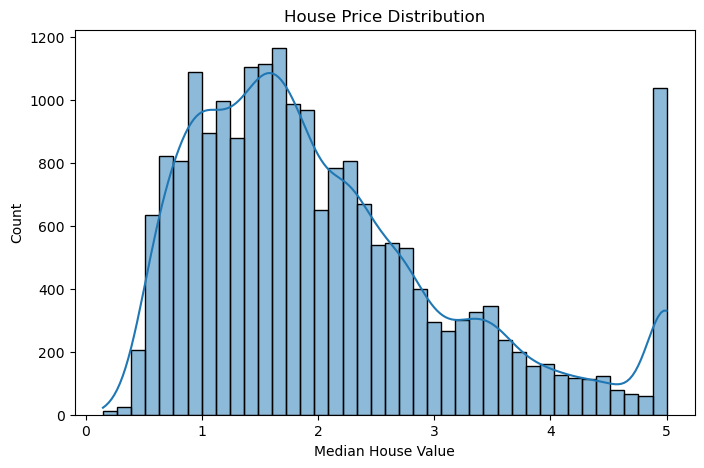

In [9]:
# Target variable ka distribution
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], kde=True, bins=40)
plt.title('House Price Distribution')
plt.xlabel('Median House Value')
plt.show()

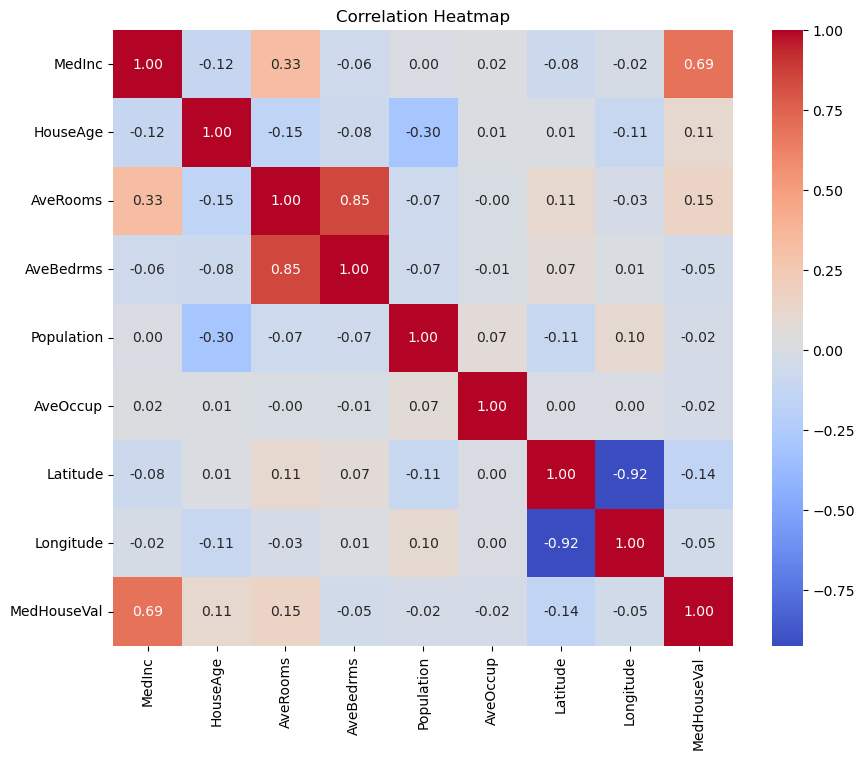

In [10]:
# Correlation heatmap - dekhte hain konse features price se zyada related hain
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

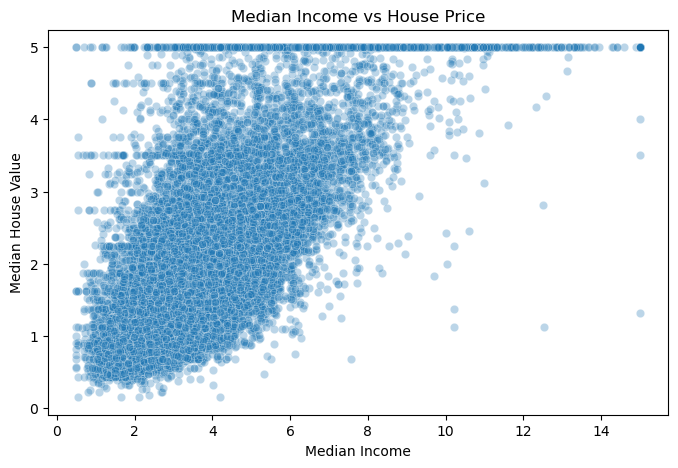

In [11]:
# Sabse zyada correlated feature (MedInc) vs target ka scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.3)
plt.title('Median Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

## Step 5: Features (X) aur Target (y) alag karna

In [12]:
X = df.drop('MedHouseVal', axis=1)   # sabhi input features
y = df['MedHouseVal']                 # target jo predict karna hai

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


## Step 6: Train-Test Split

Data ko training (80%) aur testing (20%) set mein baantte hain.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (16512, 8)
Testing set size: (4128, 8)


## Step 7: Feature Scaling (StandardScaler)

Linear Regression jaise models ke liye scaling zaroori hai taaki sabhi features same scale par aa jayein.

**Important:** `fit_transform` sirf training data par karte hain, test data par sirf `transform` (data leakage avoid karne ke liye).

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")     

Scaling complete!


## Step 8: Model Train karna (Linear Regression)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model training complete!")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {model.intercept_:.4f}")

Model training complete!

Model Coefficients:
  MedInc: 0.8544
  HouseAge: 0.1225
  AveRooms: -0.2944
  AveBedrms: 0.3393
  Population: -0.0023
  AveOccup: -0.0408
  Latitude: -0.8969
  Longitude: -0.8698

Intercept: 2.0719


## Step 9: Predictions nikalna

In [16]:
y_pred = model.predict(X_test_scaled)

# Kuch predictions actual values se compare karte hain
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## Step 10: Model Evaluation

Regression problems mein accuracy nahi, balki yeh metrics use hote hain:

- **MAE (Mean Absolute Error)**: Average mein prediction actual value se kitni door hai
- **MSE (Mean Squared Error)**: Errors ko square karke average nikalta hai (badi errors ko zyada penalize karta hai)
- **RMSE (Root Mean Squared Error)**: MSE ka square root, original units mein error batata hai
- **R² Score**: 0 se 1 ke beech — 1 ke jitna kareeb, model utna accha (kitna variance model explain kar pa raha hai)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2 Score : {r2:.4f}")

MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R2 Score : 0.5758


## Step 11: Results Visualize karna

Agar points red dashed line ke paas-paas hain, iska matlab hai model achha predict kar raha hai.

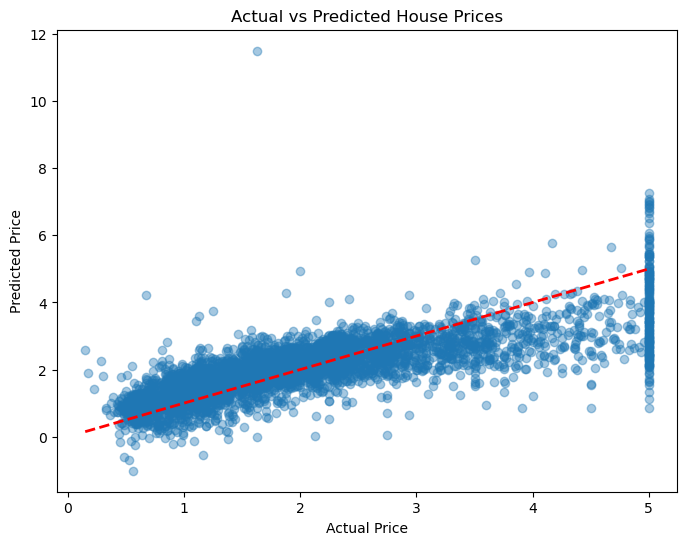

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.show()

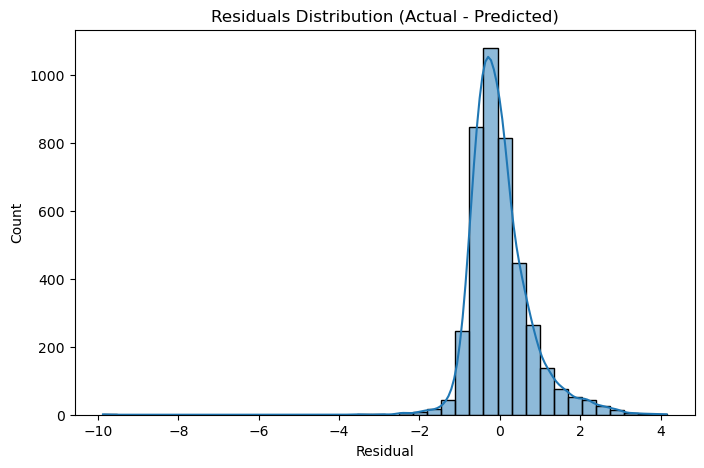

In [19]:
# Residuals (errors) ka distribution dekhna
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, bins=40)
plt.title('Residuals Distribution (Actual - Predicted)')
plt.xlabel('Residual')
plt.show()

## Conclusion

Is notebook mein humne ek complete basic Machine Learning Regression pipeline banaya:

1. Data load aur clean kiya
2. EDA se data ko samjha
3. Features scale kiye
4. Linear Regression model train kiya
5. Model ko evaluate kiya (MAE, RMSE, R²)

**Next steps (agar aage improve karna ho):**
- Doosre models try karein (Random Forest Regressor, Gradient Boosting) aur compare karein
- Hyperparameter tuning karein (`GridSearchCV`)
- Feature engineering karke naye useful features banayein
- Apna khud ka dataset use karke same pipeline apply karein


In [20]:
import joblib

# Model aur scaler dono ek saath dictionary mein save karna
joblib.dump({"model": model, "scaler": scaler}, "house_price_model.pkl")
print("Saved!")

Saved!
